In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Carica i piani abitativi
plans = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\woningbouwplannen_geojson_lnglat.json",
                      on_invalid="ignore")
print(f"Elementi caricati: {len(plans)}")
print(plans.columns.tolist())
plans.head()

Elementi caricati: 2437
['Projectnaam', 'Project_ID', 'Fase_ID', 'Fase', 'Start_bouw', 'Totaal', 'Sociale_huur', 'Middeldure_huur', 'Dure_huur', 'Dure_huur_of_Koop', 'Koop', 'Nader_te_bepalen', 'Tijdelijk_Onzelfstandig', 'Stadsdeelcode', 'Stadsdeel', 'Gebiedcode', 'Gebied', 'Projectgebied', 'geometry']


,Projectnaam,Project_ID,Fase_ID,Fase,Start_bouw,Totaal,Sociale_huur,Middeldure_huur,Dure_huur,Dure_huur_of_Koop,Koop,Nader_te_bepalen,Tijdelijk_Onzelfstandig,Stadsdeelcode,Stadsdeel,Gebiedcode,Gebied,Projectgebied,geometry
0,BSH k48 PO B16-22,6447,5,In aanbouw genomen,2020,7,0,0,0,0,7,0,0,N,Noord,GN19,Oud-Noord,Oud-Noord,"MULTIPOLYGON (((4.90015 52.39377, 4.89997 52.3..."
1,BSH k48/49 cluster C,8441,5,In aanbouw genomen,2022,155,0,0,0,0,155,0,0,N,Noord,GN19,Oud-Noord,Buiksloterham,"POLYGON ((4.90088 52.39324, 4.90112 52.39277, ..."
2,BSH k6A Klaprozenweg 19-27,8087,5,In aanbouw genomen,2022,72,0,0,72,0,0,0,0,N,Noord,GN19,Oud-Noord,OudNoord,"POLYGON ((4.90917 52.39657, 4.90953 52.39642, ..."
3,BSH WK1 / CPO Waterkavels,7300,5,In aanbouw genomen,2018,45,0,0,0,0,45,0,0,N,Noord,GN19,Oud-Noord,Oud-Noord,"POLYGON ((4.90734 52.3943, 4.90485 52.39525, 4..."
4,BSHk3D^Poppies,7480,5,In aanbouw genomen,2022,100,0,100,0,0,0,0,0,N,Noord,GN19,Oud-Noord,OudNoord,"POLYGON ((4.90577 52.3985, 4.90632 52.39829, 4..."


In [2]:
print("Fasi dei progetti:")
print(plans['Fase'].value_counts())
print(f"\nAnni di costruzione:")
print(plans['Start_bouw'].value_counts().sort_index().tail(20))

Fasi dei progetti:
Fase
In aanbouw genomen             1576
Investeringsbesluit genomen     659
Principebesluit genomen         182
Verkenning                       18
                                  2
Name: count, dtype: int64

Anni di costruzione:
Start_bouw
2026    254
2027     77
2028    104
2029     83
2030     55
2031     38
2032     39
2033     31
2034     27
2035     29
2036     39
2037     17
2038     14
2039     11
2040     21
2041      5
2042      4
2043      4
2044      5
2045      4
Name: count, dtype: int64


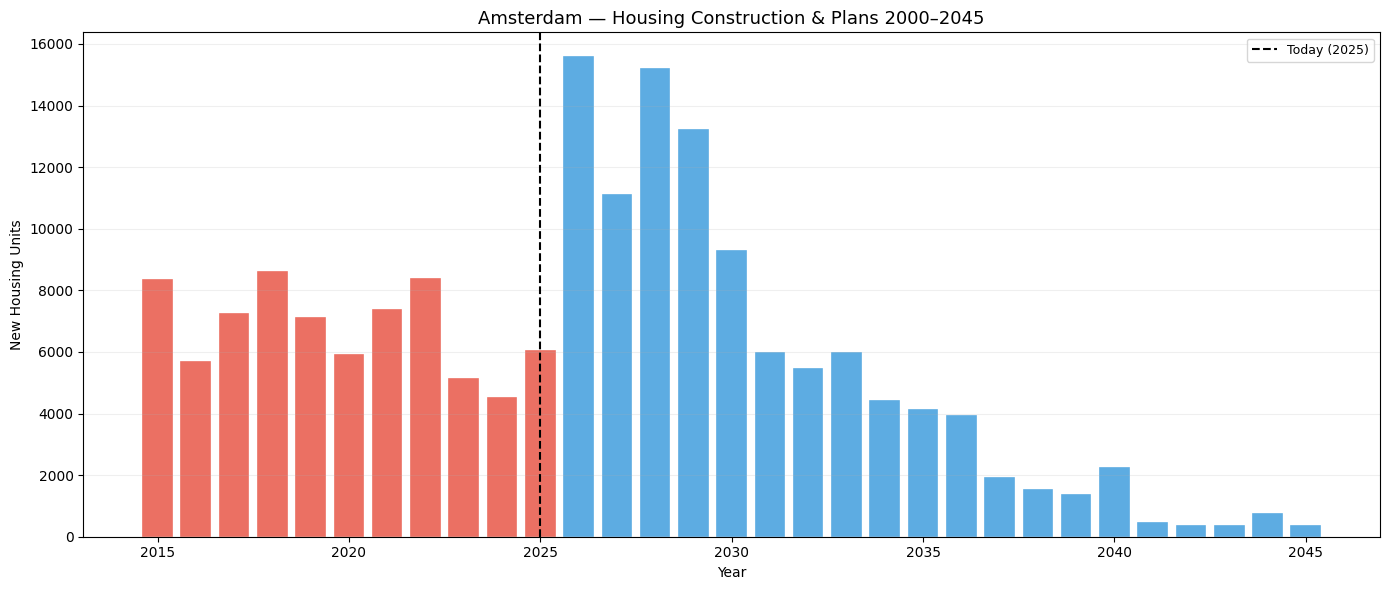

In [3]:
# Abitazioni per anno di costruzione
case_per_anno = plans.groupby('Start_bouw')['Totaal'].sum().reset_index()
case_per_anno.columns = ['Anno', 'Abitazioni']
case_per_anno = case_per_anno[case_per_anno['Anno'] > 2000]

fig, ax = plt.subplots(figsize=(14, 6))

colori = ['#e74c3c' if anno <= 2025 else '#3498db' 
          for anno in case_per_anno['Anno']]

ax.bar(case_per_anno['Anno'], case_per_anno['Abitazioni'],
       color=colori, alpha=0.8, edgecolor='white', linewidth=0.3)

ax.axvline(x=2025, color='black', linestyle='--', linewidth=1.5, label='Today')
ax.set_title('Amsterdam — Housing Construction & Plans 2000–2045', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('New Housing Units')
ax.legend(['Today (2025)'], fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('amsterdam_housing_plans.png', dpi=150, bbox_inches='tight')
plt.show()

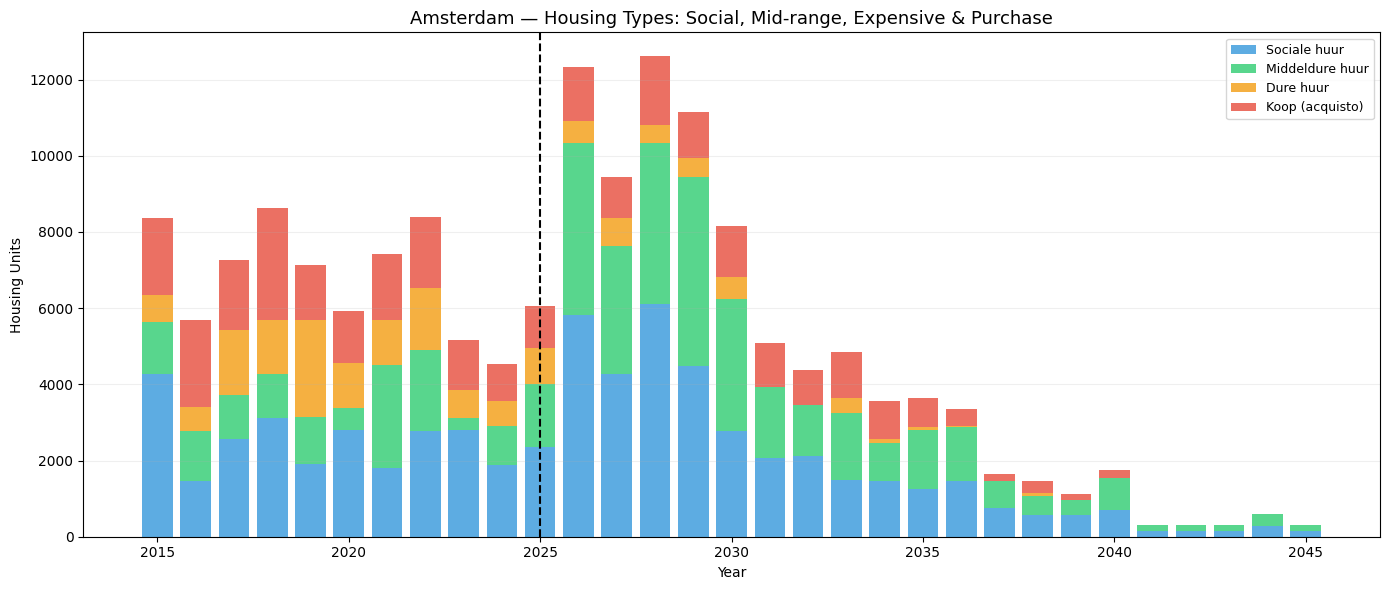

In [4]:
# Tipologie di abitazioni pianificate
tipologie = plans.groupby('Start_bouw')[
    ['Sociale_huur', 'Middeldure_huur', 'Dure_huur', 'Koop']
].sum().reset_index()
tipologie = tipologie[tipologie['Start_bouw'] > 2000]

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(tipologie['Start_bouw'], tipologie['Sociale_huur'], 
       label='Sociale huur', color='#3498db', alpha=0.8)
ax.bar(tipologie['Start_bouw'], tipologie['Middeldure_huur'],
       bottom=tipologie['Sociale_huur'],
       label='Middeldure huur', color='#2ecc71', alpha=0.8)
ax.bar(tipologie['Start_bouw'], tipologie['Dure_huur'],
       bottom=tipologie['Sociale_huur'] + tipologie['Middeldure_huur'],
       label='Dure huur', color='#f39c12', alpha=0.8)
ax.bar(tipologie['Start_bouw'], tipologie['Koop'],
       bottom=tipologie['Sociale_huur'] + tipologie['Middeldure_huur'] + tipologie['Dure_huur'],
       label='Koop (acquisto)', color='#e74c3c', alpha=0.8)

ax.axvline(x=2025, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Amsterdam — Housing Types: Social, Mid-range, Expensive & Purchase', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Housing Units')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('amsterdam_housing_types.png', dpi=150, bbox_inches='tight')
plt.show()

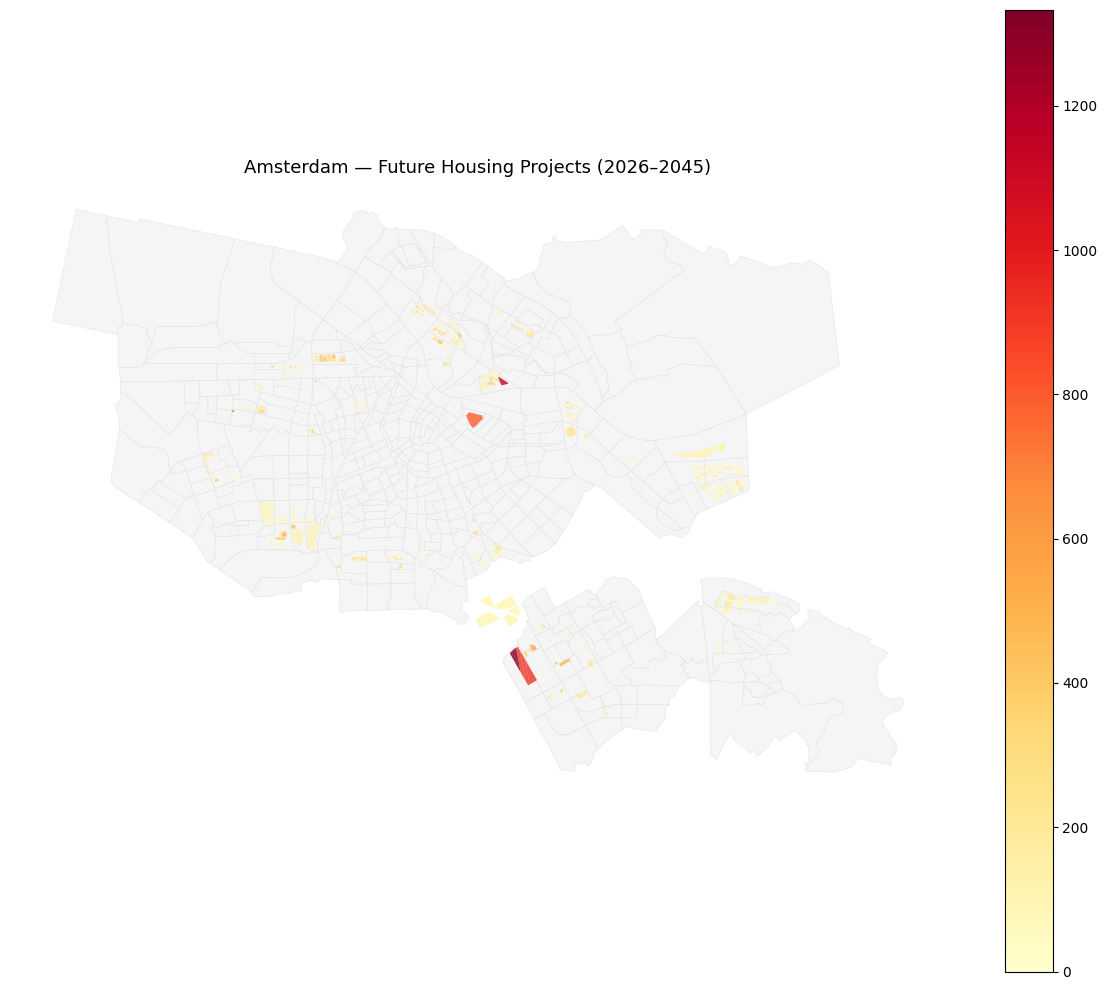

In [5]:
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
plans_proj = plans.to_crs(buurten.crs)

# Solo progetti futuri
futuri = plans_proj[plans_proj['Start_bouw'] > 2025]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

futuri.plot(
    column='Totaal',
    cmap='YlOrRd',
    ax=ax,
    legend=True,
    alpha=0.8,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Amsterdam — Future Housing Projects (2026–2045)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_future_map.png', dpi=150, bbox_inches='tight')
plt.show()

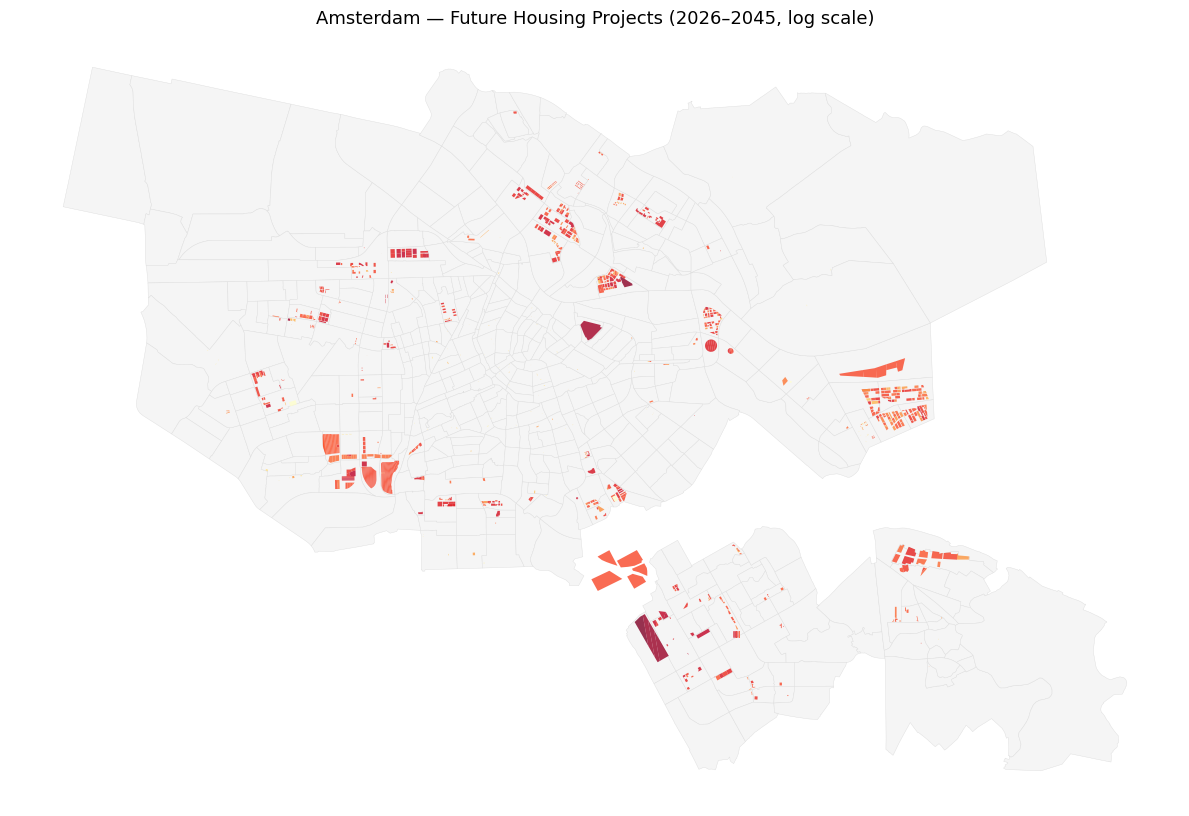

In [6]:
import numpy as np

plans_proj_futuri = futuri.copy()
plans_proj_futuri['Totaal_log'] = np.log10(plans_proj_futuri['Totaal'] + 1)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

plans_proj_futuri.plot(
    column='Totaal_log',
    cmap='YlOrRd',
    ax=ax,
    legend=False,
    alpha=0.8
)

ax.set_title('Amsterdam — Future Housing Projects (2026–2045, log scale)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_future_map_log.png', dpi=150, bbox_inches='tight')
plt.show()